# Customer Churn Prediction - Summary
This notebook presents key insights, model metrics, and business recommendations for customer churn prediction.  
All plots and code are minimized for GitHub-friendly rendering.


In [2]:
import pandas as pd

# Load dataset
data/churn.csv
# Clean column names
df.columns = df.columns.str.strip()


In [3]:
# Target distribution
churn_distribution = df['Churn'].value_counts(normalize=True) * 100
churn_distribution


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

- ~26.5% of customers churned → class imbalance present


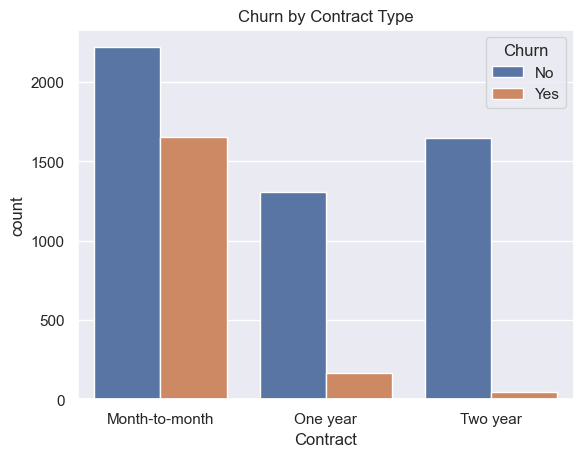

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")

# Churn by Contract Type
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()


**Insights:**
- Month-to-month customers have higher churn
- Shorter tenure → higher churn
- Higher monthly charges → higher churn
- Electronic check users → higher churn
- Fiber optic users → higher churn


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Preprocessing
df.drop(columns=['customerID'], inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.dropna(inplace=True)
df_encoded = pd.get_dummies(df, drop_first=True)

num_cols = ['tenure', 'MonthlyCharges']
df_encoded[num_cols] = StandardScaler().fit_transform(df_encoded[num_cols])

# Train-test split
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

ROC AUC: 0.840367873104446


- Incentivize month-to-month users to shift to long-term contracts
- Focus retention campaigns on early-tenure customers
- Review pricing strategy for high monthly charge segments
- Improve payment experience for electronic check users
